# 5. Uncertainty and variance across datasets

<a href="https://colab.research.google.com/github/jmoortgat/GasBrineBench/blob/main/notebooks/05_uncertainty_and_variance.ipynb" target="_blank" rel="noopener noreferrer"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>


Three kinds of uncertainty can be read from this database:

1. the **stated** uncertainty of a source (where there is one);
2. the **empirical** scatter between independent sources that measured the same property at about the same conditions
   (`data/consensus/`); and
3. the **quality code** (R, T, U), which records whether independent sources agree.

Stated uncertainties exist for only part of the data and describe repeatability within a laboratory; the scatter between laboratories is
usually larger. Both are shown. How the consensus statistic is defined, and its limits, is in `data/consensus/README.md`.

> **Running on Google Colab?** Click the badge above and run the cells; nothing needs to be installed. The first code cell detects
> Colab, clones the repository into `/content/GasBrineBench`, checks that pandas, numpy and matplotlib are present (Colab already has them)
> and changes into `notebooks/`, so everything after it works as on a local checkout. Locally the cell does nothing but confirm the layout.
> To use a fork or a branch, set `GBB_REPO_URL` and `GBB_BRANCH` before the cell runs.

In [1]:
# --- Colab / local bootstrap ---------------------------------------------------------------------------------
# On Colab this cell clones the repository and installs anything missing; on a local checkout it only confirms the layout.
# Re-running it is safe.
import os, subprocess, sys
from pathlib import Path

REPO_URL = os.environ.get("GBB_REPO_URL", "https://github.com/jmoortgat/GasBrineBench.git")
BRANCH = os.environ.get("GBB_BRANCH", "main")
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB or os.environ.get("GBB_FORCE_BOOTSTRAP"):
    REPO_DIR = Path("/content/GasBrineBench") if IN_COLAB else Path(os.environ.get("GBB_CLONE_DIR", "GasBrineBench_clone")).resolve()
    if not REPO_DIR.exists():
        print(f"cloning {REPO_URL} ({BRANCH}) into {REPO_DIR}")
        subprocess.check_call(["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, str(REPO_DIR)])
    else:
        print(f"repository already cloned at {REPO_DIR}")
    missing = []
    for pkg, mod in [("pandas", "pandas"), ("numpy", "numpy"), ("matplotlib", "matplotlib")]:
        try:
            __import__(mod)
        except ImportError:
            missing.append(pkg)
    if missing:
        print("pip install -q", " ".join(missing))
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    os.chdir(REPO_DIR / "notebooks")
    print("cwd =", os.getcwd())
else:
    print("local environment: using the existing checkout")

local environment: using the existing checkout


In [2]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")
HERE = pathlib.Path.cwd()
ROOT = HERE if (HERE / "gasbrinebench").exists() else HERE.parent
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT / "notebooks"))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import gasbrinebench as gbb
from gasbrinebench.vocab import DEFAULT_EXCLUDED_FLAGS
import gbb_viz as V
V.style()
# default view (what a benchmark user scores) and the view that also keeps rows without a stated pressure
df = gbb.load()
dfp = gbb.load(exclude_flags=tuple(f for f in DEFAULT_EXCLUDED_FLAGS if f != "pressure-unstated"))
dfall = gbb.load(exclude_tags=None, exclude_flags=None)
print(f"{len(dfall):,} rows in total, {len(df):,} in the default view, gasbrinebench {gbb.__version__}")

27,025 rows in total, 23,300 in the default view, gasbrinebench 1.2.0


In [3]:
rows = pd.read_csv(ROOT / "data" / "consensus" / "consensus_rows.csv")
bysrc = pd.read_csv(ROOT / "data" / "consensus" / "consensus_by_source.csv")
rows["outlier"] = rows.consensus_outlier.astype(str) == "True"
print(f"{len(rows):,} rows have at least one independent comparator ({len(rows) / len(df):.0%} of the default view)")

3,510 rows have at least one independent comparator (15% of the default view)


## Stated uncertainties

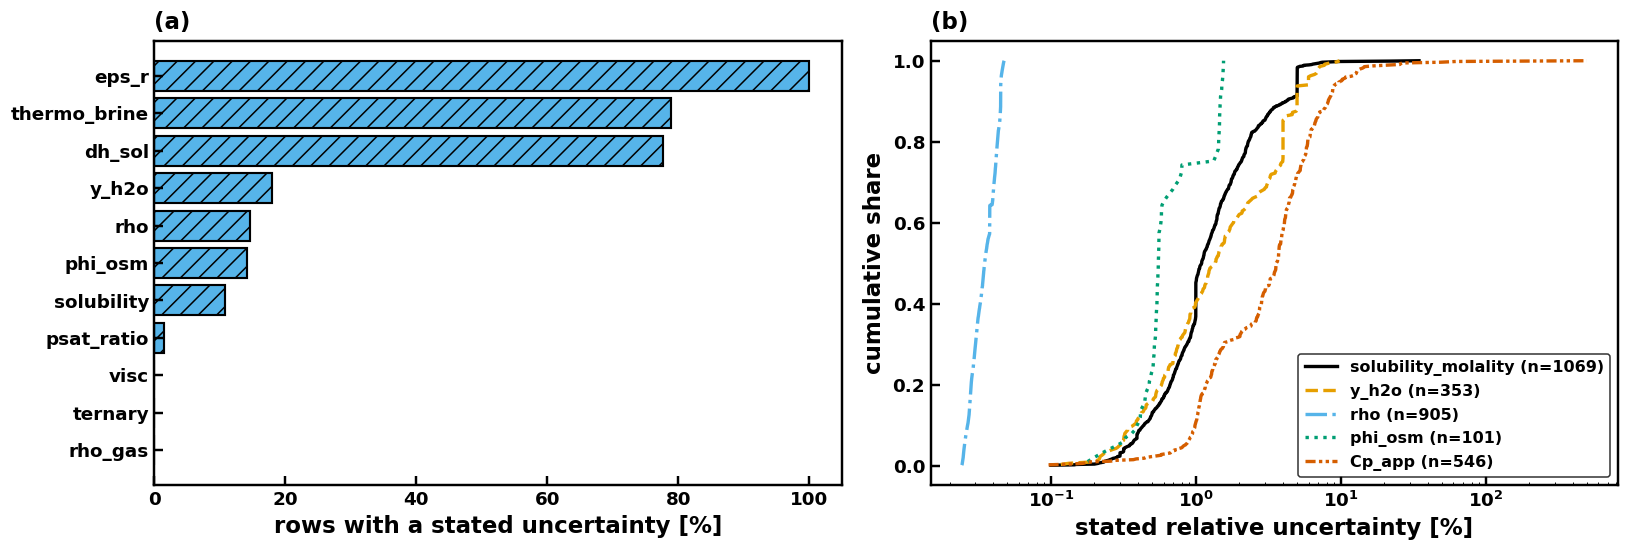

In [4]:
has = dfall.groupby("family").apply(lambda g: g.uncertainty.notna().mean()).sort_values()
u = dfall[dfall.uncertainty.notna() & (dfall.value != 0)].copy()
u["rel"] = (u.uncertainty / u.value.abs()).clip(lower=1e-5)
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
axes[0].barh(has.index, has.values * 100, color="#56B4E9", edgecolor="black", linewidth=1.4, hatch="//")
V.lab(axes[0], "rows with a stated uncertainty [%]", "", "(a)")
for k, (p, g) in enumerate([("solubility_molality", u[u.property == "solubility_molality"]), ("y_h2o", u[u.property == "y_h2o"]), ("rho", u[u.property == "rho"]), ("phi_osm", u[u.property == "phi_osm"]), ("Cp_app", u[u.property == "Cp_app"])]):
    if len(g) < 5: continue
    x = np.sort(g.rel.values * 100)
    axes[1].plot(x, np.arange(1, len(x) + 1) / len(x), color=V.WONG[k % 7], ls=V.LINESTYLES[k % 5], label=f"{p} (n={len(g)})")
axes[1].set_xscale("log"); axes[1].legend(loc="lower right"); V.lab(axes[1], "stated relative uncertainty [%]", "cumulative share", "(b)")
plt.tight_layout(); plt.show()

## Disagreement between independent sources

`rel_dev` is the signed relative difference between a row and the median of the other sources at about the same state (strict
tolerances: 1 K, 2 % in pressure and molalities); `rel_dev_smooth` comes from a leave-one-source-out local fit and covers more rows.

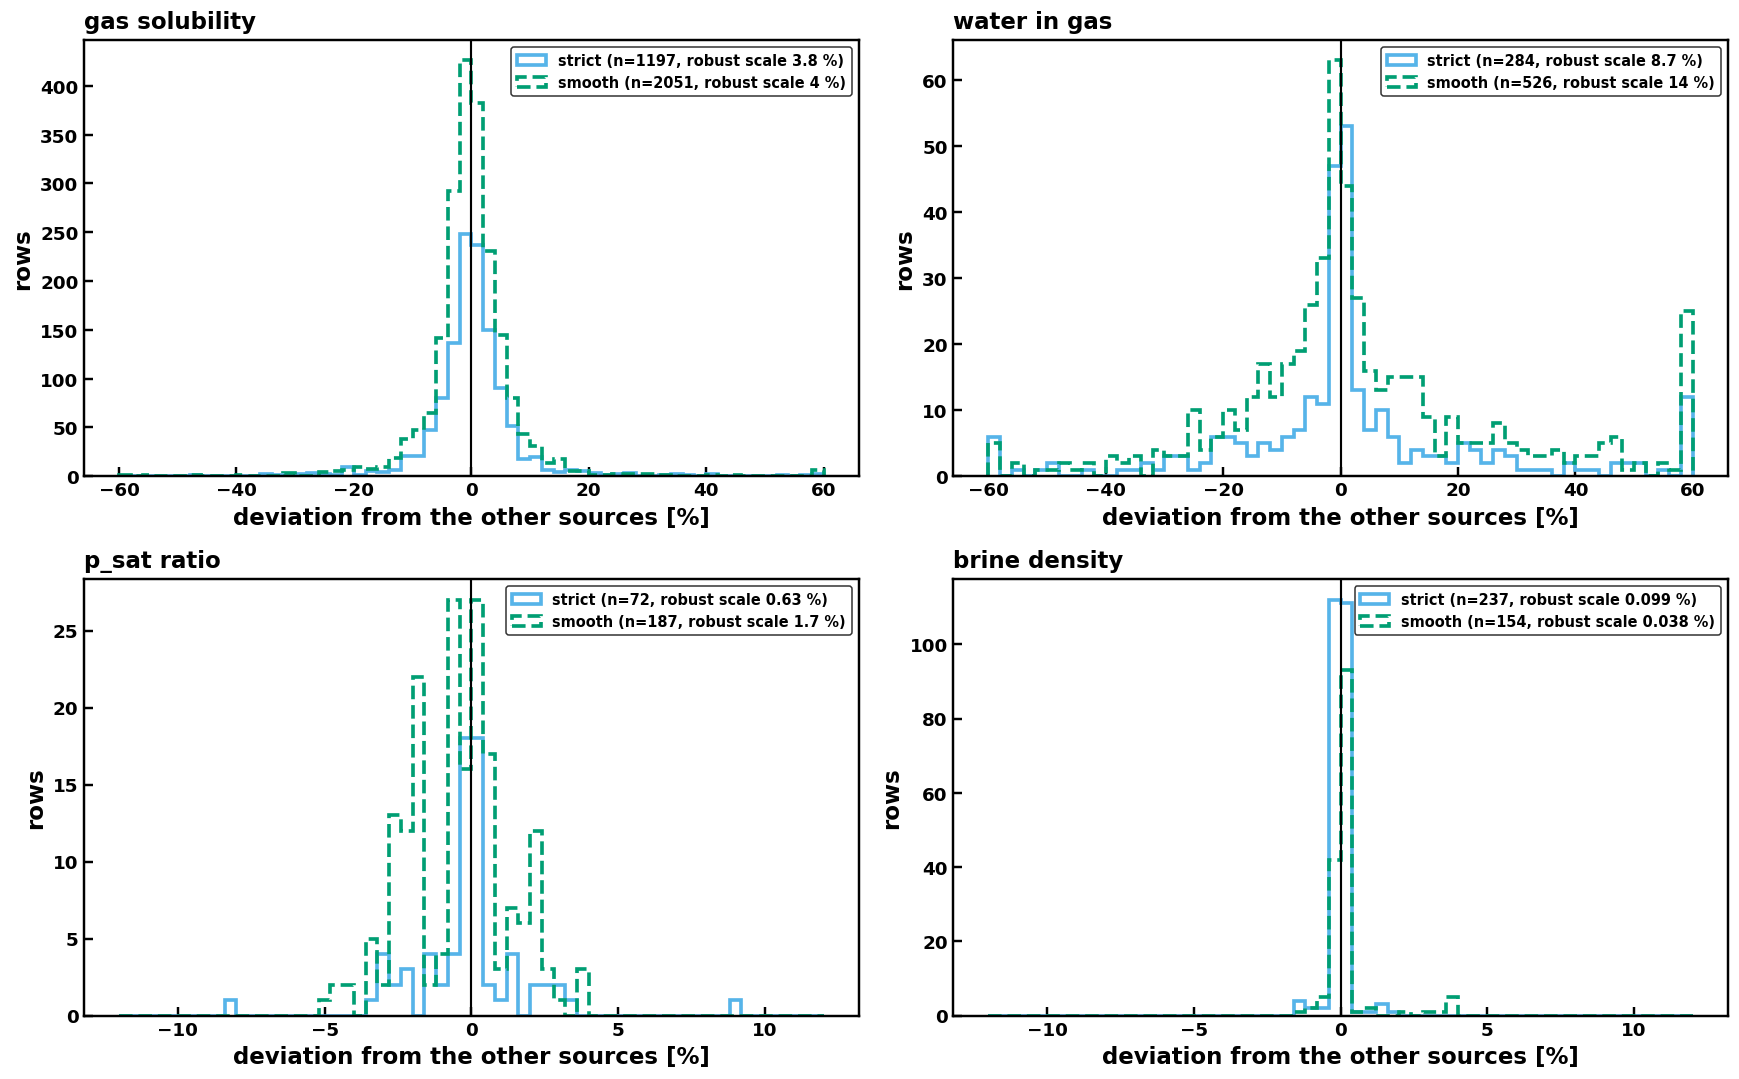

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, (p, lab_) in zip(axes.ravel(), [("solubility_molality", "gas solubility"), ("y_h2o", "water in gas"), ("psat_ratio", "p_sat ratio"), ("rho", "brine density")]):
    g = rows[rows.property == p]
    for k, (c, name, ls) in enumerate([("rel_dev", "strict", "-"), ("rel_dev_smooth", "smooth", "--")]):
        x = g[c].dropna() * 100
        if len(x) < 10: continue
        lim = 60 if p in ("solubility_molality", "y_h2o") else 12
        ax.hist(x.clip(-lim, lim), bins=np.linspace(-lim, lim, 61), histtype="step", lw=2.4, ls=ls, color=V.WONG[k + 2], label=f"{name} (n={len(x)}, robust scale {1.4826 * np.median(np.abs(x - np.median(x))):.2g} %)")
    ax.axvline(0, color="black", lw=1.4); ax.legend(loc="upper right", fontsize=9.5); V.lab(ax, "deviation from the other sources [%]", "rows", lab_)
plt.tight_layout(); plt.show()

## Does the disagreement depend on temperature, pressure, salinity?

Absolute deviation of gas-solubility rows from the consensus, with the median in bins. Disagreement that grows with a variable points to
a regime where the methods diverge (near the critical point, at high pressure, at high salinity).

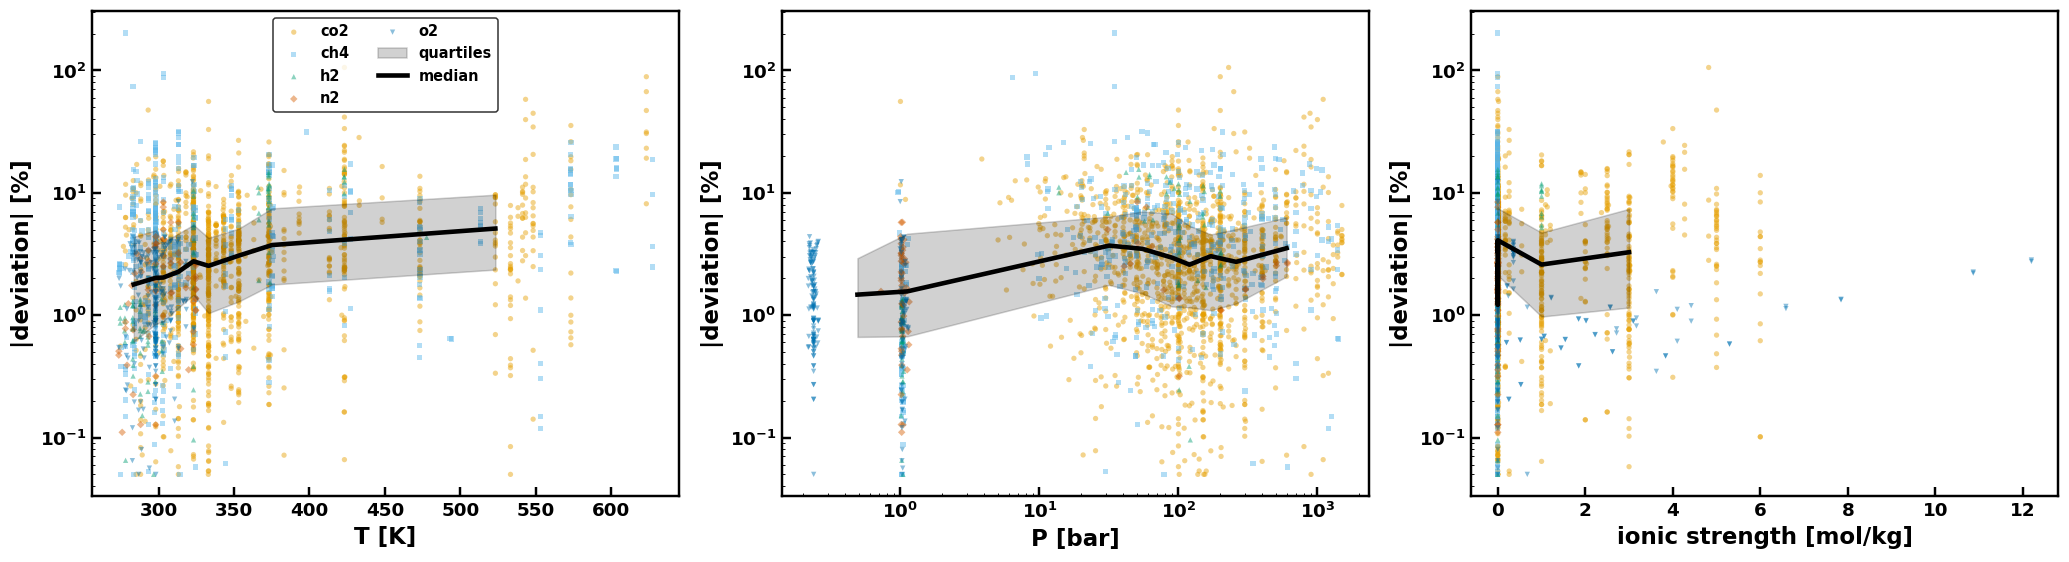

In [6]:
g = rows[(rows.property == "solubility_molality")].copy()
g["dev"] = g.rel_dev_smooth.fillna(g.rel_dev).abs() * 100
g["I"] = (g[["m_Na", "m_K", "m_Cl"]].sum(axis=1) + 3 * (g.m_Ca + g.m_Mg) + 2 * g.m_SO4) / 2
fig, axes = plt.subplots(1, 3, figsize=(19, 5.3))
for ax, (x, lab_, logx) in zip(axes, [("T_K", "T [K]", False), ("P_bar", "P [bar]", True), ("I", "ionic strength [mol/kg]", False)]):
    for k, gas in enumerate(["co2", "ch4", "h2", "n2", "o2"]):
        w = g[g.gas == gas]
        ax.scatter(w[x], w.dev.clip(lower=0.05), s=12, color=V.WONG[(k + 1) % 7], marker=V.MARKERS[k], alpha=0.45, edgecolor="none", label=gas if x == "T_K" else None)
    tx, tm, tlo, thi = V.qtrend(g[x], g.dev, nbins=9)
    if len(tx):
        ax.fill_between(tx, tlo, thi, color="black", alpha=0.18, label="quartiles" if x == "T_K" else None)
        ax.plot(tx, tm, color="black", lw=3, label="median" if x == "T_K" else None)
    ax.set_yscale("log");
    if logx: ax.set_xscale("log")
    V.lab(ax, lab_, "|deviation| [%]")
axes[0].legend(ncol=2, fontsize=9.5)
plt.tight_layout(); plt.show()

## How far is each source from the others?

Median deviation of each source (sources with at least ten compared rows); the horizontal bar is the robust scatter of that source's own deviations.
A source on the zero line agrees with its neighbours on average; one far from it has a calibration, method or basis difference that a
user should know about. Marker shape separates the property families.

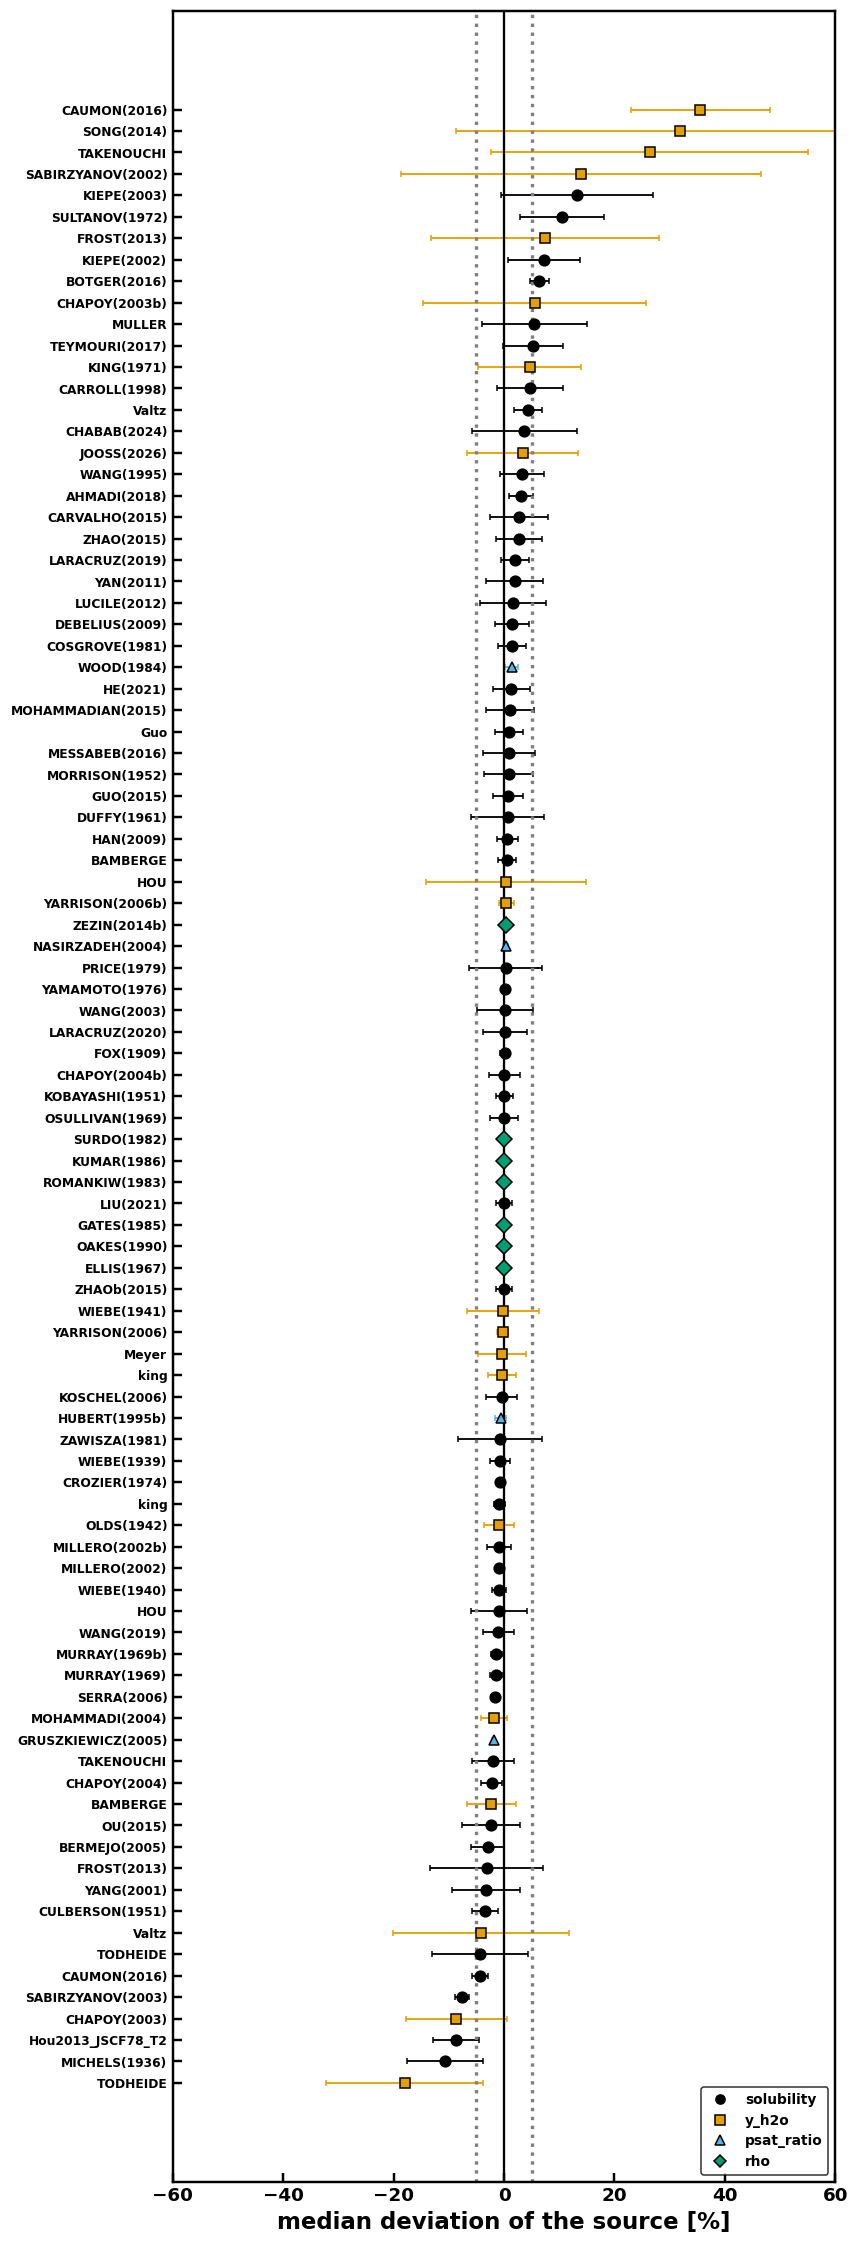

In [7]:
t = bysrc[(bysrc.smooth_n_compared >= 10) | (bysrc.strict_n_compared >= 10)].copy()
t["bias"] = t.smooth_bias_median.fillna(t.strict_bias_median) * 100
t["scale"] = t.smooth_scale_mad.fillna(t.strict_scale_mad) * 100
t = t.sort_values("bias").reset_index(drop=True)
fig, ax = plt.subplots(figsize=(8, 0.2 * len(t) + 2))
fm = {"solubility": ("o", "#000000"), "y_h2o": ("s", "#E69F00"), "psat_ratio": ("^", "#56B4E9"), "rho": ("D", "#009E73"), "thermo_brine": ("v", "#D55E00"), "dh_sol": ("P", "#CC79A7")}
for i, r in t.iterrows():
    m, c = fm.get(r.family, ("o", "gray"))
    ax.errorbar(r.bias, i, xerr=r.scale, fmt=m, color=c, mec="black", ms=7, elinewidth=1.2, capsize=2)
ax.set_yticks(range(len(t))); ax.set_yticklabels(t.source, fontsize=8); ax.axvline(0, color="black", lw=1.5); ax.axvline(-5, color="gray", ls=":"); ax.axvline(5, color="gray", ls=":")
ax.set_xlim(-60, 60)
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([], [], marker=m, color=c, mec="black", ls="", label=f) for f, (m, c) in fm.items() if f in set(t.family)], loc="lower right", fontsize=9)
V.lab(ax, "median deviation of the source [%]", ""); plt.tight_layout(); plt.show()

## Variance across datasets at one state

States of pure-water CO2 solubility that several independent sources measured within 1 K and 2 % in pressure. For each state, the values
of the sources relative to their median: the vertical spread at a state is the between-laboratory variance, the horizontal line the median.

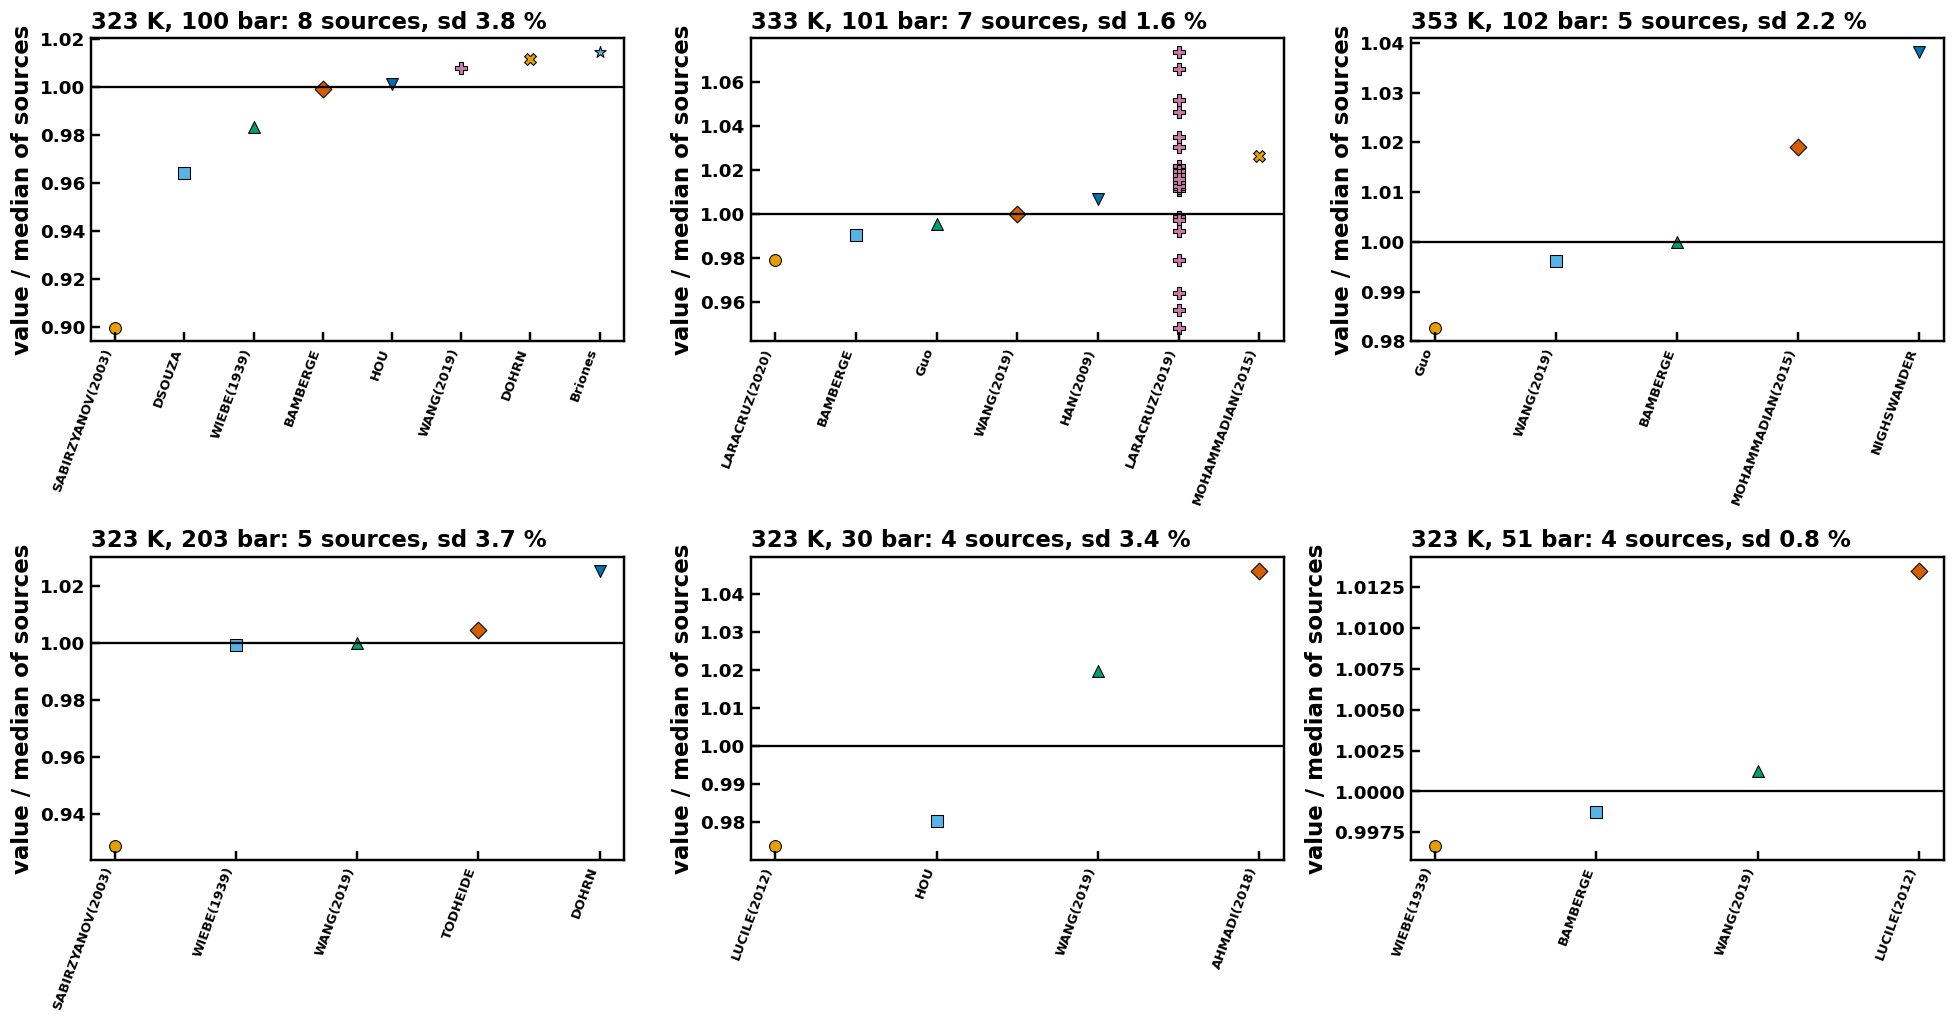

In [8]:
s = df[(df.property == "solubility_molality") & (df.gas == "co2") & (df.total_molality == 0)].copy()
s["src"] = s.source
best = []
for i, r in s.iterrows():
    w = s[(abs(s.T_K - r.T_K) <= 1) & (abs(s.P_bar - r.P_bar) <= 0.02 * r.P_bar)]
    best.append((w.src.nunique(), r.T_K, r.P_bar))
best = pd.DataFrame(best, columns=["n", "T", "P"]).sort_values("n", ascending=False).drop_duplicates(["T", "P"])
chosen = []
for _, r in best.iterrows():
    if all(abs(r["T"] - c["T"]) > 4 or abs(r["P"] - c["P"]) > 0.15 * c["P"] for c in chosen): chosen.append(r)
    if len(chosen) == 6: break
fig, axes = plt.subplots(2, 3, figsize=(18, 9.5))
for ax, r in zip(axes.ravel(), chosen):
    w = s[(abs(s.T_K - r["T"]) <= 1) & (abs(s.P_bar - r["P"]) <= 0.02 * r["P"])]
    med = w.groupby("src").value.median(); ref = med.median()
    names = list(med.sort_values().index)
    for k, n in enumerate(names):
        v = w[w.src == n]
        ax.scatter([k] * len(v), v.value / ref, s=60, color=V.WONG[(k % 6) + 1], marker=V.MARKERS[k % 12], edgecolor="black", linewidth=0.7)
    ax.axhline(1, color="black", lw=1.5)
    ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=70, ha="right", fontsize=8.5)
    V.lab(ax, "", "value / median of sources", f"{r['T']:.0f} K, {r['P']:.0f} bar: {len(names)} sources, sd {np.std(med / ref, ddof=1) * 100:.1f} %")
plt.tight_layout(); plt.show()

## Quality codes against deviation

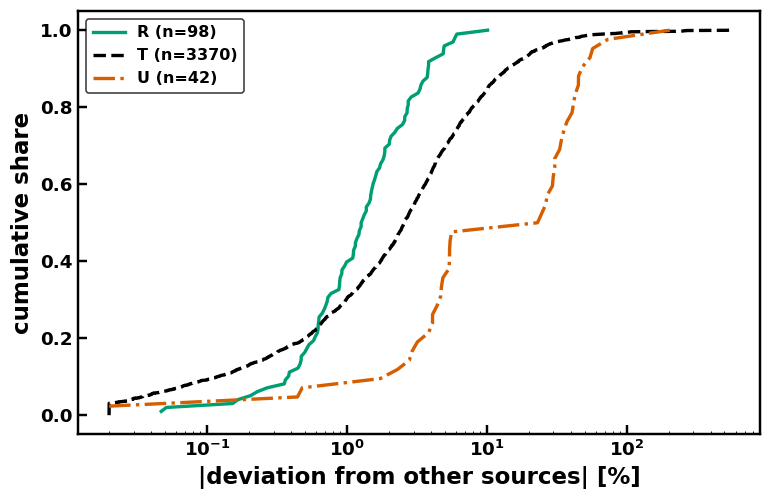

In [9]:
d = rows.copy()
d["dev"] = d.rel_dev.fillna(d.rel_dev_smooth).abs() * 100
d = d.merge(dfall.groupby(["dataset_id"]).quality.agg(lambda x: x.mode().iloc[0]).rename("q"), left_on="dataset_id", right_index=True, how="left")
fig, ax = plt.subplots(figsize=(8, 5))
for k, q in enumerate(["R", "T", "U"]):
    x = np.sort(d[d.q == q].dev.dropna());
    if len(x): ax.plot(np.clip(x, 0.02, None), np.arange(1, len(x) + 1) / len(x), color=V.WONG[[3, 0, 4][k]], ls=V.LINESTYLES[k], label=f"{q} (n={len(x)})")
ax.set_xscale("log"); ax.legend(); V.lab(ax, "|deviation from other sources| [%]", "cumulative share"); plt.show()

## The rows that still disagree most

Listed, not removed: the disagreement is a property of the literature.

In [10]:
o = rows[rows.outlier].copy(); o["dev"] = o.rel_dev_smooth.fillna(o.rel_dev)
display(o.reindex(o.dev.abs().sort_values(ascending=False).index).head(25)[["source", "dataset_id", "gas", "property", "T_K", "P_bar", "value", "reference", "ref_smooth", "dev", "n_other_sources", "n_other_smooth"]].round(4))
print(o.groupby("source").size().sort_values(ascending=False).head(12).to_dict())

,source,dataset_id,gas,property,T_K,P_bar,value,reference,ref_smooth,dev,n_other_sources,n_other_smooth
3144,TAKENOUCHI,yh2o_co2_binary,co2,y_h2o,423.150,1400.0000,0.2460,NaN,0.0675,2.6466,0,2
3143,TAKENOUCHI,yh2o_co2_binary,co2,y_h2o,423.150,1300.0000,0.2420,NaN,0.0669,2.6163,0,2
3142,TAKENOUCHI,yh2o_co2_binary,co2,y_h2o,423.150,1200.0000,0.2360,NaN,0.0663,2.5577,0,2
3141,TAKENOUCHI,yh2o_co2_binary,co2,y_h2o,423.150,1100.0000,0.2300,NaN,0.0657,2.5000,0,2
3140,TAKENOUCHI,yh2o_co2_binary,co2,y_h2o,423.150,1000.0000,0.2200,0.0650,0.0650,2.3846,1,2
3280,king,yh2o_co2_binary,co2,y_h2o,288.150,51.7000,0.0022,0.0006,0.0007,2.3355,1,4
3139,TAKENOUCHI,yh2o_co2_binary,co2,y_h2o,423.150,900.0000,0.2060,NaN,0.0640,2.2184,0,2
2121,SONG(1997),song1997_10.1016_s0378-3812(96)03165-2_t1,ch4,solubility_molality,278.150,34.5000,0.2006,0.0661,0.0663,2.0230,1,7
3281,king,yh2o_co2_binary,co2,y_h2o,293.150,58.8000,0.0026,0.0009,0.0009,2.0173,1,3
3074,HOU,yh2o_co2_binary,co2,y_h2o,323.150,10.9000,0.0281,NaN,0.0117,1.4069,0,3


{'TAKENOUCHI': 22, 'TODHEIDE': 13, 'MICHELS(1936)': 8, 'CAUMON(2016)': 7, 'SABIRZYANOV(2002)': 6, 'FROST(2013)': 6, 'SONG(2014)': 6, 'SONG(1987)': 5, 'KIEPE(2003)': 5, 'WANG(2019)': 5, 'CARROLL(1998)': 5, 'Hou2013_JSCF78_T2': 5}
